# Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from skimage.measure import shannon_entropy
from skimage.morphology import white_tophat, disk
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.exposure import rescale_intensity
from skimage.util import img_as_float, img_as_ubyte
from skimage.restoration import denoise_bilateral
from scipy.ndimage import laplace
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import random

# Visualización de datos

In [2]:
DATA_DIR = Path("data")
image_files = list(DATA_DIR.glob("*.jpg"))

statistics = []
corrupted_files = []

In [3]:
for img_file in tqdm(image_files, desc="Processing images"):
    try:
        with Image.open(img_file) as img:
            img_gray = img.convert('L')
            img_array_gray = np.array(img_gray)
            img_array = np.array(img)

            width, height = img.size
            mode = img.mode

            # Look for NaN values in the image array
            has_nan = np.isnan(img_array).any()

            #  Pixel value statistics
            mean_val = np.mean(img_array)
            std_val = np.std(img_array)
            min_val = np.min(img_array)
            max_val = np.max(img_array)

            # Entropy: Measure of complexity/information content
            ent = shannon_entropy(img_array)
            
            # Sharpness: Variance of the Laplacian
            sharpness = np.var(laplace(img_array_gray))

            statistics.append({
                "filename": img_file.name,
                "width": width,
                "height": height,
                "mode": mode,
                "mean_intensity": mean_val,
                "std_intensity": std_val,
                "min_intensity": min_val,
                "max_intensity": max_val,
                "entropy": ent,
                "sharpness": sharpness,
                "has_nan": has_nan
            })
    except Exception as e:
        # If there's an corrupted file
        corrupted_files.append({'filename': img_file.name, 'error': str(e)})

df  = pd.DataFrame(statistics)

Processing images: 100%|██████████| 5446/5446 [04:50<00:00, 18.73it/s]


## Estadisticas descriptivas

In [4]:
corrupted_files

[{'filename': 'J154951.73+160402.5.jpg',
  'error': 'image file is truncated (80 bytes not processed)'},
 {'filename': 'J114739.51+100035.4.jpg',
  'error': 'image file is truncated (93 bytes not processed)'},
 {'filename': 'J134807.42+144711.9.jpg',
  'error': 'image file is truncated (8 bytes not processed)'},
 {'filename': 'J142043.76+053351.6.jpg',
  'error': 'image file is truncated (110 bytes not processed)'},
 {'filename': 'J150244.67+261252.1.jpg',
  'error': 'image file is truncated (99 bytes not processed)'},
 {'filename': 'J160131.59+362834.9.jpg',
  'error': 'image file is truncated (44 bytes not processed)'},
 {'filename': 'J143659.70+133059.7.jpg',
  'error': 'image file is truncated (109 bytes not processed)'},
 {'filename': 'J234447.50+254133.9.jpg',
  'error': 'image file is truncated (51 bytes not processed)'},
 {'filename': 'J145430.69+094226.1.jpg',
  'error': 'image file is truncated (52 bytes not processed)'},
 {'filename': 'J152516.45+532425.4.jpg',
  'error': 'i

In [5]:
df.head()

,filename,width,height,mode,mean_intensity,std_intensity,min_intensity,max_intensity,entropy,sharpness,has_nan
0,J115411.04+305652.3.jpg,800,800,RGB,40.513945,30.896488,0,255,6.336151,14140.743585,False
1,J090105.65+082536.7.jpg,800,800,RGB,37.123586,26.803691,0,255,6.368993,13101.412283,False
2,J070552.49+655739.9.jpg,800,800,RGB,36.745555,22.203929,0,255,5.971673,10077.102353,False
3,J083907.66+043402.4.jpg,800,800,RGB,53.435871,42.205530,0,255,6.662711,11292.742344,False
4,J103154.70-031818.9.jpg,800,800,RGB,34.319342,20.750330,0,255,6.150319,12495.401202,False


In [6]:
df.describe()

,width,height,mean_intensity,std_intensity,min_intensity,max_intensity,entropy,sharpness
count,5003.0,5003.0,5003.000000,5003.000000,5003.000000,5003.000000,5003.000000,5003.000000
mean,800.0,800.0,40.309662,27.918231,0.031581,254.568259,6.293839,13425.265836
std,0.0,0.0,10.278925,6.440160,0.964899,5.656597,0.321319,1233.313304
min,800.0,800.0,31.961873,0.000000,0.000000,32.000000,0.000000,0.000000
25%,800.0,800.0,36.755140,23.927473,0.000000,255.000000,6.153893,12977.203434
50%,800.0,800.0,38.564674,27.241475,0.000000,255.000000,6.309219,13696.863947
75%,800.0,800.0,41.401478,30.945381,0.000000,255.000000,6.464228,14241.604985
max,800.0,800.0,219.912874,100.133838,41.000000,255.000000,7.734024,15249.277823


## Visualización

/tmp/ipykernel_62774/634956432.py:31: RuntimeWarning: overflow encountered in scalar add
  plt.text(i, v + 2, f'{v:.2f}', ha='center', fontweight='bold')


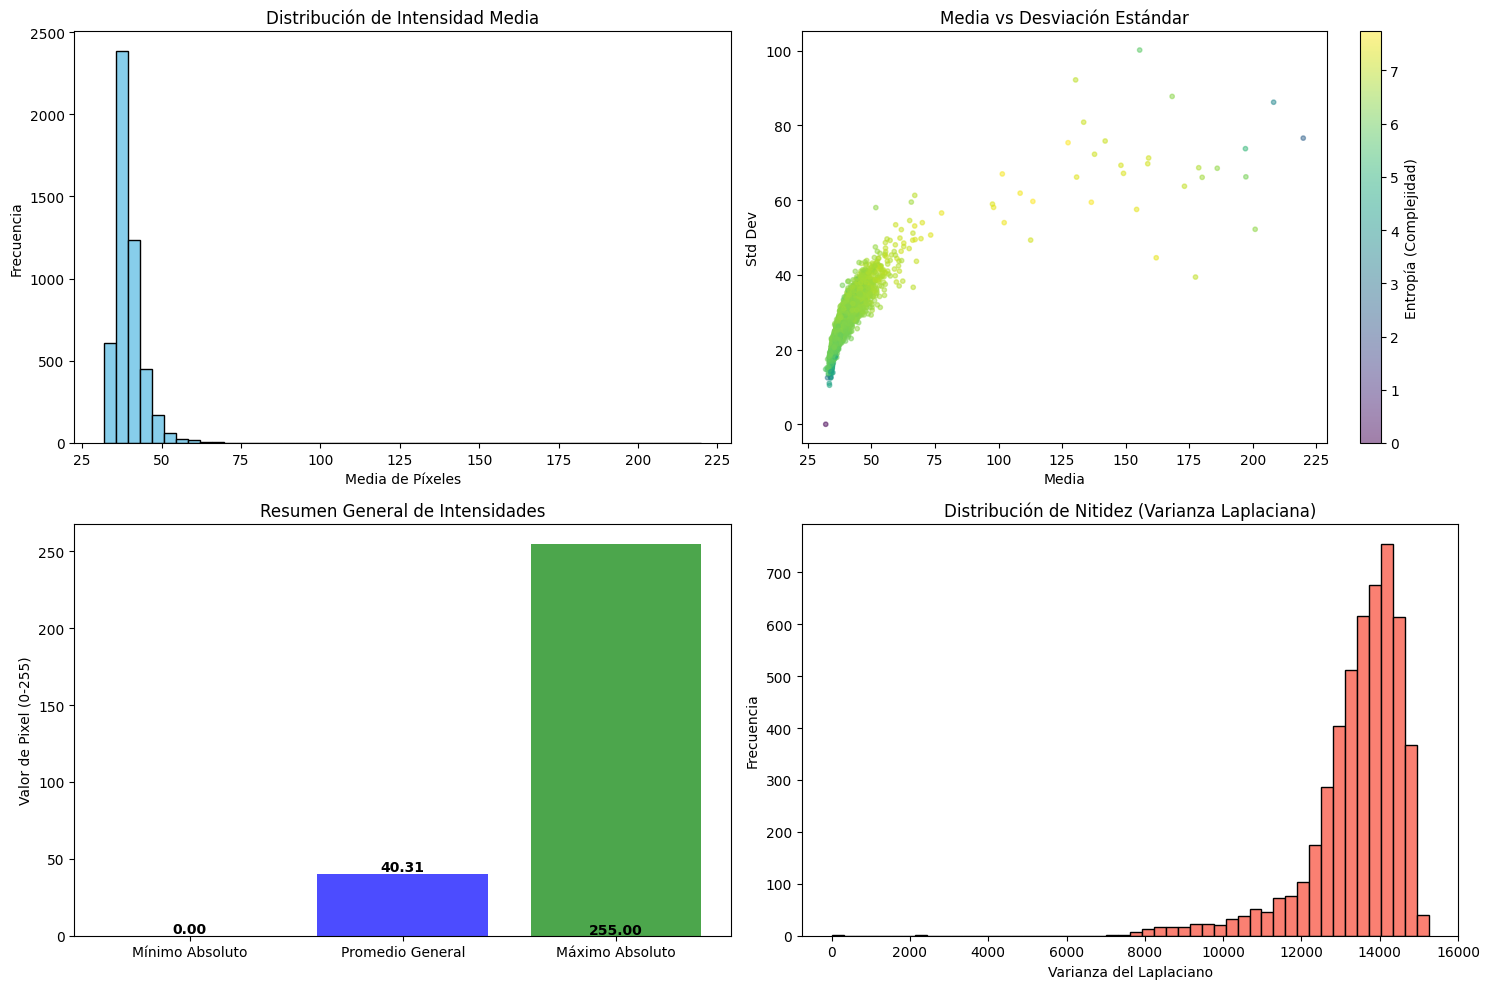

In [7]:
plt.figure(figsize=(15, 10))
# Subplot 1: Histogram of intensities
plt.subplot(2, 2, 1)
plt.hist(df['mean_intensity'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de Intensidad Media')
plt.xlabel('Media de Píxeles')
plt.ylabel('Frecuencia')

# Subplot 2: Mean vs Std (Contrast)
plt.subplot(2, 2, 2)
plt.scatter(df['mean_intensity'], df['std_intensity'], alpha=0.5, s=10, c=df['entropy'], cmap='viridis')
plt.colorbar(label='Entropía (Complejidad)')
plt.title('Media vs Desviación Estándar')
plt.xlabel('Media')
plt.ylabel('Std Dev')

# Subplot 3: Bar chart of global Min, Mean, Max
plt.subplot(2, 2, 3)
global_min = df['min_intensity'].min()
global_mean = df['mean_intensity'].mean()
global_max = df['max_intensity'].max()

labels = ['Mínimo Absoluto', 'Promedio General', 'Máximo Absoluto']
values = [global_min, global_mean, global_max]
colors = ['red', 'blue', 'green']

plt.bar(labels, values, color=colors, alpha=0.7)
plt.title('Resumen General de Intensidades')
plt.ylabel('Valor de Pixel (0-255)')
for i, v in enumerate(values):
    plt.text(i, v + 2, f'{v:.2f}', ha='center', fontweight='bold')

# Subplot 4: Sharpness Distribution
plt.subplot(2, 2, 4)
plt.hist(df['sharpness'], bins=50, color='salmon', edgecolor='black')
plt.title('Distribución de Nitidez (Varianza Laplaciana)')
plt.xlabel('Varianza del Laplaciano')
plt.ylabel('Frecuencia')

plt.tight_layout()

plt.tight_layout()

El análisis estadístico exploratorio sobre la muestra de 5003 imágenes revela alteraciones estructurales severas derivadas de la codificación y compresión del dataset original. La distribución de la nitidez, calculada con la varianza del Laplaciano e ilustrada en el cuarto gráfico del panel, muestra una media poblacional anormalmente alta de 13,425.26. En el análisis de imágenes astronómicas, esta métrica no representa una alta fidelidad en los bordes de las galaxias, sino que cuantifica la dominancia masiva de ruido estocástico de alta frecuencia a nivel de píxel. Este problema de ruido se ve exacerbado por una saturación artificial del rango dinámico: la tabla estadística y el gráfico de resumen general evidencian que, a partir del percentil 25, el valor máximo de intensidad (`max_intensity`) ya alcanza el límite de 255. Esto demuestra que los archivos JPEG sufrieron una expansión de contraste agresiva previa a su entrega, la cual amplificó el ruido de fondo y los artefactos cromáticos, justificando matemáticamente la aplicación del filtro bilateral para estabilizar la entropía local.

Adicionalmente, el análisis descriptivo permitió aislar discontinuidades críticas que comprometerían la convergencia de cualquier arquitectura de segmentación auto-supervisada. Los registros de valores mínimos detectaron tensores con una desviación estándar, entropía y nitidez equivalentes a 0.000000, limitados a un `max_intensity` de 32.0. Esto prueba empíricamente la existencia de matrices planas, carentes de información morfológica. Paralelamente, el histograma de distribución de intensidad media (primer gráfico) exhibe un comportamiento nominal concentrando la densidad probabilística entre los valores 35 y 45 (con una media global de 40.30); sin embargo, expone anomalías que alcanzan una intensidad media máxima de 219.91. La identificación documentada de estos valores atípicos extremos y matrices corruptas provee la fundamentación técnica definitiva sobre la necesidad de descartar métodos de mapeo no lineal e implementar recortes basados en percentiles para preservar la integridad espacial de la señal.

# Sample size

La fórmula de Cochran es una aproximación estadística basada en el Teorema del Límite Central que permite calcular el tamaño de muestra representativo para estimar proporciones poblacionales. Se utiliza cuando se busca un nivel de precisión específico, asumiendo una distribución normal de las proporciones muestrales.La Ecuación BasePara una población teóricamente infinita, o donde el tamaño total es desconocido y presumiblemente muy grande, la ecuación se define como:

$$n_0 = \frac{Z^2 p q}{e^2}$$

Donde:
- $n_0$: Es el tamaño de la muestra preliminar estimado.
- $Z$: Es el valor crítico de la distribución normal estándar que corresponde al nivel de confianza elegido (Z-score). Determina el área bajo la curva normal. Para el clásico nivel de confianza del 95%, $Z = 1.96$.
- $p$: Es la proporción esperada de la población que presenta la característica de interés. Si no se cuenta con datos históricos o estudios piloto, se estandariza asumiendo la máxima varianza posible, lo cual ocurre en $p = 0.5$.
- $q$: Es la proporción que no presenta la característica, calculada como $1 - p$. Cuando $p = 0.5$, el producto $p q$ alcanza su límite superior ($0.25$), lo que fuerza matemáticamente el cálculo a entregar el tamaño de muestra más conservador (el más grande).
- $e$: Es el margen de error absoluto tolerado, introducido en formato decimal. Un error del 5% corresponde a $e = 0.05$.Origen MatemáticoLa fórmula de Cochran no es arbitraria; se deriva directamente de la ecuación del intervalo de confianza para una proporción de Bernoulli. Si partimos de la definición del margen de error:$$e = Z \sqrt{\frac{p q}{n_0}}$$

Al aislar la variable del tamaño de la muestra elevando ambos lados al cuadrado, llegamos a la ecuación de Cochran. Expresa una relación donde el tamaño de la muestra crece en proporción directa al cuadrado de la confianza exigida y a la varianza de la población, y decrece inversamente con el cuadrado del error permitido.Corrección para Poblaciones FinitasSi el tamaño de la población total ($N$) es finito y conocido, y la estimación inicial $n_0$ excede el 5% de $N$ (es decir, $n_0 / N > 0.05$), se debe aplicar un factor de reducción. En poblaciones cerradas, extraer un individuo cambia la probabilidad de extraer al siguiente, por lo que la varianza muestral disminuye.La fórmula de ajuste es:$$n = \frac{n_0}{1 + \frac{n_0 - 1}{N}}$$Esta corrección escala iterativamente el requisito muestral. A medida que $n_0$ se acerca a $N$, el denominador aumenta, contrayendo el valor final $n$ para evitar redundancia estadística en el muestreo.

El diseño estadístico del muestreo mediante la fórmula de Cochran encuentra su justificación técnica directa en la heterogeneidad revelada por el análisis exploratorio. En el script implementado, el parámetro de proporción se fijó deliberadamente en $p = 0.5$, un valor que fuerza el cálculo para asumir el escenario de máxima varianza poblacional. Los datos empíricos demuestran que esta no fue una suposición teórica excesivamente conservadora, sino una necesidad dictada por la realidad del dataset. Al evidenciarse un espacio muestral donde coexisten matrices con entropía y desviación estándar idénticas a 0.000000, junto con tensores atípicos que alcanzan intensidades medias de 219.91 y varianzas laplacianas severas, por lo que se necesitó calcular un tamaño de muestra bajo premisas de máxima dispersión. Solo así se podía garantizar que la muestra capturara representativamente todo el espectro de anomalías y ruido cromático presente en los datos originales.

Asimismo, la delimitación exacta del universo de datos a una población de $N = 5003$ imágenes hizo indispensable la aplicación del factor de corrección para poblaciones finitas, programado en la fase final de tu algoritmo. La muestra preliminar estimada excedía con creces el umbral del 5% del total (alcanzando finalmente 880 imágenes, un 17.5% de la población). Bajo las reglas del límite central, omitir esta corrección habría resultado en un sobremuestreo redundante que incrementaría el costo computacional sin aportar mayor certidumbre estadística. En última instancia, la fórmula actuó como un blindaje metodológico: dado que la calibración de los hiperparámetros del filtro bilateral requería modelar con exactitud el error base del dataset, este enfoque garantizó una extracción fiel a la distribución real, sustentada con un nivel de confianza del 95% y un margen de error del 3%, evitando el sesgo inherente a tomar un lote aleatorio sobre un entorno de datos tan inestable.

In [8]:
def calculate_sample_size(N: int, confidence_level: float = 0.95, margin_error: float = 0.03) -> int:
    """Calcula el tamaño de muestra necesario para una población finita.
    Args:        
        N (int): Tamaño de la población.
        confidence_level (float): Nivel de confianza (default 0.95).
        margin_error (float): Margen de error permitido (default 0.03).
    Returns:        
        int: Tamaño de muestra necesario.
    """
    z_map = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    Z = z_map.get(confidence_level, 1.96) 
    p = 0.5
    n0 = (Z**2 * p * (1-p)) / (margin_error**2)
    n = n0 / (1 + (n0 - 1) / N)
    return int(np.ceil(n))

In [9]:
N = len(df)
n_target = calculate_sample_size(N)
print(f"For a population of {N}, a significant sample size is {n_target} (95% CI, 3% MoE)")

For a population of 5003, a significant sample size is 880 (95% CI, 3% MoE)


Utilizando la fórmula de Cochran con corrección para población finita (N=5003), se determinó que una muestra de 880 imágenes es
      suficiente para un 95% de confianza con un 3% de margen de error.

In [10]:
def perform_sampling(df: pd.DataFrame, target_n: int) -> pd.DataFrame:
    """
    Performs Stratified Proportional Sampling using KMeans.
    Args:
        df (pd.DataFrame): DataFrame containing image statistics.
        target_n (int): Desired sample size.
    Returns:
        pd.DataFrame: Sampled DataFrame with significant images.
    """
    print(f"\n--- Statistical Sampling (Target n={target_n}) ---")
    sampling_features = ['mean_intensity', 'std_intensity', 'entropy', 'sharpness']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[sampling_features])
    
    n_clusters = 5
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    df['strata'] = kmeans.fit_predict(X_scaled)
    
    sample_df = df.groupby('strata', group_keys=False).apply(
        lambda x: x.sample(n=int(np.ceil(target_n * len(x) / len(df))), random_state=42)
    ).head(target_n)
    
    print(f"Sample selected with {len(sample_df)} images.")
    sample_df.to_csv('significant_sample.csv', index=False)
    return sample_df

In [11]:
sample_df = perform_sampling(df, n_target)
sample_df.head()


--- Statistical Sampling (Target n=880) ---
Sample selected with 880 images.


,filename,width,height,mode,mean_intensity,std_intensity,min_intensity,max_intensity,entropy,sharpness,has_nan
528,J074321.08+173617.2.jpg,800,800,RGB,42.513907,31.711176,0,255,6.498445,13670.824544,False
1086,J115428.07+262854.5.jpg,800,800,RGB,47.811511,38.945569,0,255,6.743539,14294.641777,False
3238,J100327.20-013244.9.jpg,800,800,RGB,46.924266,41.060082,0,255,6.550957,13198.862694,False
4576,J074516.67+460758.3.jpg,800,800,RGB,45.794397,32.858985,0,255,6.370509,14190.851805,False
981,J144957.01+331357.6.jpg,800,800,RGB,43.647432,29.756518,0,255,6.343374,14755.613404,False


In [12]:
def validate_sample(population_df: pd.DataFrame, sample_df: pd.DataFrame) -> None:
    """
    Validates the sample using Kolmogorov-Smirnov test.
    Args:
        population_df (pd.DataFrame): The original population DataFrame.
        sample_df (pd.DataFrame): The sampled DataFrame to validate.
    """
    print("\n--- Statistical Validation ---")
    metrics = ['mean_intensity', 'entropy', 'sharpness']
    results = []
    for metric in metrics:
        ks_stat, p_value = stats.ks_2samp(population_df[metric], sample_df[metric])
        results.append({
            'Metric': metric,
            'KS Statistic': ks_stat,
            'P-Value': p_value,
            'Significant Difference?': 'Yes' if p_value < 0.05 else 'No'
        })
    print(pd.DataFrame(results))
    
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 3, i+1)
        plt.hist(population_df[metric], bins=30, alpha=0.5, label='Población', density=True)
        plt.hist(sample_df[metric], bins=30, alpha=0.5, label='Muestra', density=True)
        plt.title(f'Distribución de {metric}')
        plt.legend()
    plt.tight_layout()


--- Statistical Validation ---
           Metric  KS Statistic   P-Value Significant Difference?
0  mean_intensity      0.019903  0.921562                      No
1         entropy      0.019495  0.932423                      No
2       sharpness      0.023594  0.788531                      No


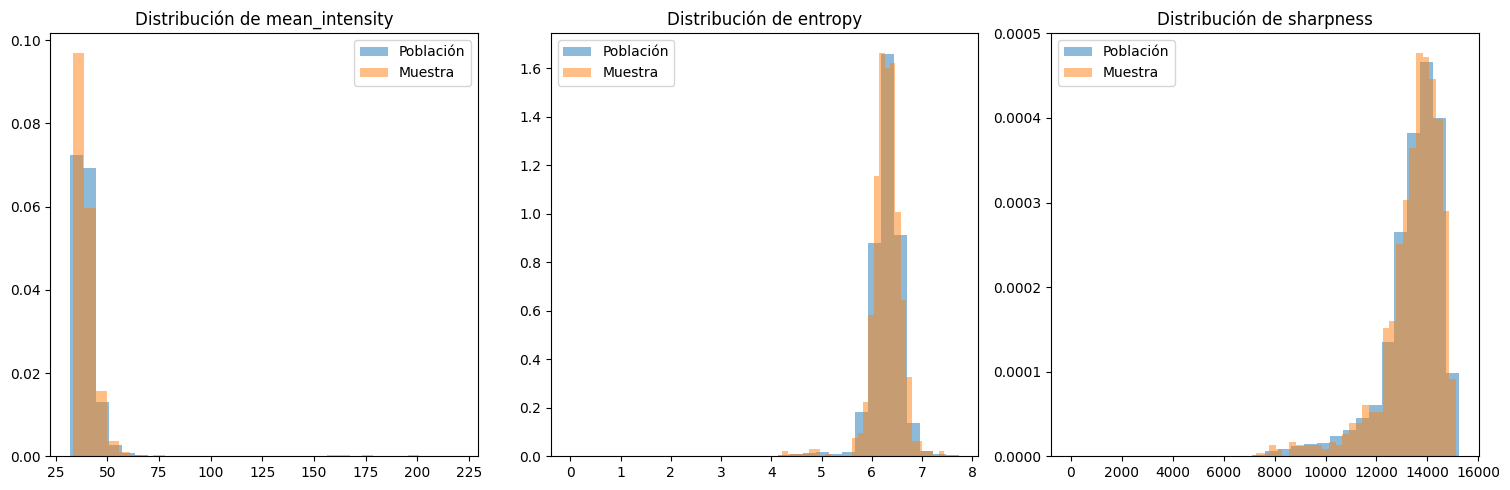

In [13]:
validate_sample(df, sample_df)


Se utilizó K-Means para agrupar las imágenes en 5 estratos (basados en intensidad, entropía y nitidez) y asegurar que la muestra
      conserve la diversidad del dataset original (imágenes oscuras, complejas, con mucho ruido, etc.). La prueba de Kolmogorov-Smirnov confirmó que no hay diferencias significativas entre la muestra y la población (P-values > 0.78 para todas las
      métricas).

# Limpieza de las imágenes

Los resultados estadísticos indican tres problemas en el dataset original:

1. Mediana ~0.13 - 0.14:
En una imagen astronómica ideal, el espacio profundo debería tener un valor cercano a 0 pero los datos indican que todo el fondo está elevado artificialmente, ocupando casi el 14% deñ-l rango dinámico. Esto significa que las imágenes están sobreexpuestas. 

2. Sigma p95 de 0.1221 en R vs 0.0756 en B
La diferencia de varianza entre el canal rojo y el azul nos dice que el ruido del dataset no es de origen puramente óptico o térmico, sino que es un artefacto de la compresión JPEG (probablemente). El canal rojo está degradado y contiene picos de ruido esporádicos que un modelo convolucional interpretaría erróneamente como pequeñas estructuras físicas.

3. Rango Dinámico Comprimido: Peak SNR < 10 en R
El Peak SNR de 9.89 en el canal rojo es una relación señal-ruido baja. Significa que, en el peor de los casos, la parte más brillante de la galaxia es apenas 10 veces más intensa que las fluctuaciones del ruido de fondo. El verdadero problema aquí está en los bordes: la intensidad de los halos difusos de la galaxia tiene prácticamente la misma amplitud matemática que los picos del ruido.

Por lo tanto el dataset original es una mezcla de señal óptica débil bajo un nivel de negro artificialmente alto y corrompida por artefactos de compresión asimétricos.
El pipeline implementando (Filtro Bilateral + clipping lineal) fue necesario precisamente para disminuir la mediana de 14% a cero y suavizar la asimetría del canal rojo sin destruir los pocos gradientes válidos que definen la morfología de la galaxia.

In [14]:
CSV_PATH = Path('significant_sample.csv')
SOURCE_PATH = Path('data')
TARGET_PATH = Path('data/cleaned_sample')

sample_df = pd.read_csv(CSV_PATH)

## Analisis estadistico del sample

In [15]:
def analyze_dataset_stats(csv_path='significant_sample.csv', source_dir='data'):
    df = pd.read_csv(csv_path)
    source_path = Path(source_dir)
    
    # Arreglos para almacenar métricas de todo el dataset
    bg_estimates = {'R': [], 'G': [], 'B': []}
    sigma_estimates = {'R': [], 'G': [], 'B': []}
    snr_estimates = {'R': [], 'G': [], 'B': []}
    
    print(f"--- Iniciando Extracción Estadística Global: {len(df)} imágenes ---")
    
    for filename in tqdm(df['filename'], desc="Analizando varianza y señal"):
        img_file = source_path / filename
        if not img_file.exists():
            continue
            
        try:
            with Image.open(img_file) as img:
                img_array = img_as_float(np.array(img))
            
            # Procesamiento para RGB
            if img_array.ndim == 3:
                for i, color in enumerate(['R', 'G', 'B']):
                    channel = img_array[:,:,i]
                    
                    median_bg = np.median(channel)
                    mad = stats.median_abs_deviation(channel.flatten())
                    sigma_est = 1.4826 * mad
                    
                    max_val = np.max(channel)
                    snr_peak = (max_val - median_bg) / sigma_est if sigma_est > 0 else 0
                    
                    bg_estimates[color].append(median_bg)
                    sigma_estimates[color].append(sigma_est)
                    snr_estimates[color].append(snr_peak)
        except Exception as e:
            print(f"Error procesando matriz de {filename}: {e}")
            
    # Cálculo de hiperparámetros globales del dataset
    print("\n--- Resultados Globales del Dataset ---")
    for color in ['R', 'G', 'B']:
        if not bg_estimates[color]:
            continue
            
        global_bg = np.median(bg_estimates[color])
        global_sigma = np.median(sigma_estimates[color])
        global_snr = np.median(snr_estimates[color])
        max_sigma = np.percentile(sigma_estimates[color], 95) # Varianza en el peor escenario (p95)
        
        print(f"\nCanal {color}:")
        print(f"  Fondo base global (Mediana): {global_bg:.4f}")
        print(f"  Ruido típico (Sigma mediana): {global_sigma:.4f}")
        print(f"  Ruido máximo esperado (Sigma p95): {max_sigma:.4f}")
        print(f"  Peak SNR global representativo: {global_snr:.2f}")

if __name__ == "__main__":
    analyze_dataset_stats()

--- Iniciando Extracción Estadística Global: 880 imágenes ---


Analizando varianza y señal: 100%|██████████| 880/880 [00:48<00:00, 18.12it/s]


--- Resultados Globales del Dataset ---

Canal R:
  Fondo base global (Mediana): 0.1412
  Ruido típico (Sigma mediana): 0.0872
  Ruido máximo esperado (Sigma p95): 0.1221
  Peak SNR global representativo: 9.89

Canal G:
  Fondo base global (Mediana): 0.1333
  Ruido típico (Sigma mediana): 0.0640
  Ruido máximo esperado (Sigma p95): 0.0872
  Peak SNR global representativo: 13.55

Canal B:
  Fondo base global (Mediana): 0.1333
  Ruido típico (Sigma mediana): 0.0581
  Ruido máximo esperado (Sigma p95): 0.0756
  Peak SNR global representativo: 13.43


El código implementa un pipeline de preprocesamiento en dos fases matemáticas diseñadas para acondicionar tensores antes de introducirlos a una red convolucional. Aquí está el desglose técnico de lo que ocurre en cada etapa.

### 1. Filtrado Bilateral (`denoise_bilateral`)

Un filtro gaussiano estándar suaviza una imagen calculando un promedio ponderado de los píxeles vecinos, donde el peso disminuye únicamente en función de la distancia espacial. El problema es que esto difumina los bordes morfológicos.

El filtro bilateral resuelve esto operando simultáneamente en dos dominios: el espacial y el radiométrico (intensidad). El peso de un píxel vecino en la convolución depende del producto de dos distribuciones gaussianas:

1. **Dominio espacial (`sigma_spatial=15`):** Penaliza los píxeles que están geográficamente lejos del píxel central dentro de la ventana de convolución de $9 \times 9$ (`win_size=9`).
2. **Dominio radiométrico (`sigma_color=0.05`):** Penaliza los píxeles cuya intensidad difiere significativamente de la del píxel central.

**Comportamiento resultante:** Si el filtro encuentra una región de fondo (ruido de baja amplitud), la diferencia de intensidad es menor a $0.05$, por lo que el filtro promedia los píxeles y aplasta la varianza del ruido. Si el filtro choca contra el borde de una galaxia, la diferencia de intensidad salta. La componente radiométrica reduce el peso de ese píxel casi a cero, bloqueando el difuminado a través de esa frontera de contraste. Esto reduce la entropía estocástica del fondo conservando el gradiente original de la estructura.

### 2. Normalización Lineal Robusta (Recorte por Percentiles)

La normalización estándar Min-Max, definida como $x' = \frac{x - \min(x)}{\max(x) - \min(x)}$, es matemáticamente frágil frente a valores atípicos. Un solo píxel caliente (valor máximo del sensor) o un píxel muerto comprimirá el rango dinámico de la señal real.

El bloque de código sustituye los mínimos y máximos absolutos por umbrales estadísticos extraídos de la función de densidad acumulada de la matriz:

* **`p_low` (1.0%):** Descarta el 1% inferior del histograma. Elimina el ruido de corriente oscura del sensor o el pedestal de nivel de negro que no contiene información estructural.
* **`p_high` (99.5%):** Descarta el 0.5% superior. Corta la influencia de píxeles saturados o artefactos de compresión extremos.

La fórmula de reescalado $x' = \frac{x - p_{low}}{p_{high} - p_{low}}$ se aplica a la señal recortada. Posteriormente, `np.clip` restringe coercitivamente cualquier valor residual (los *outliers* que quedaron fuera de los percentiles) al rango numérico de $[0, 1]$.

El resultado es que el rango dinámico útil (la señal real de la galaxia y sus halos) se expande linealmente para ocupar toda la profundidad de bits disponible, sin que las funciones no lineales (como logaritmos o raíces) distorsionen las relaciones de intensidad originales que la red neuronal necesita para extraer características.

La fundamentación matemática del pipeline de preprocesamiento emana directamente de las anomalías paramétricas extraídas del muestreo. En primer lugar, la severa asimetría de la varianza —evidenciada por un ruido máximo (Sigma p95) de 0.1221 en el canal rojo frente a 0.0756 en el azul— demuestra la dominancia de artefactos de compresión no gaussianos; esto invalida los filtros espaciales lineales y exige un filtro bilateral, cuyo discriminador radiométrico aplasta el granulado cromático estocástico sin difuminar los gradientes de las estructuras reales. Simultáneamente, el desplazamiento del nivel de negro hacia una mediana global de ~0.14 revela un pedestal de ruido artificial que compromete la segmentación espacial. En lugar de aplicar sustracciones morfológicas destructivas, este piso estocástico se neutraliza acotando el umbral inferior de normalización al percentil 1.0, descartando la base de ruido sin alterar la matriz subyacente. Finalmente, la precaria relación señal-ruido del canal rojo (Peak SNR de 9.89) prohíbe categóricamente el uso de mapeos tonales no lineales. Dado que funciones como el arcoseno hiperbólico amplificarían el fondo residual hasta fusionarlo con los halos difusos de la galaxia, el reescalado lineal mediante recortes estadísticos se vuelve mandatorio. Este método distribuye el rango de interés uniformemente en el intervalo [0, 1], preservando las distancias matemáticas originales entre intensidades para entregar tensores estables que permitan la convergencia espacial en la red convolucional.

In [16]:
def deep_learning_prep_pipeline(img_array):
    """
    Pipeline optimizado para preservar gradientes espaciales 
    para modelos de segmentación convolucional.
    """
    img_float = img_as_float(img_array)
    
    # Filtrado Bilateral: Reduce ruido de alta frecuencia en el fondo 
    # mientras preserva estrictamente los bordes
    # sigma_color: Controla cuánto se mezclan colores distintos. Un valor bajo evita difuminar bordes.
    # sigma_spatial: Radio de influencia espacial.
    denoised = denoise_bilateral(
        img_float, 
        win_size=9, 
        sigma_color=0.05, 
        sigma_spatial=15, 
        channel_axis=-1
    )
    
    # Normalización Lineal Robusta
    # Evitamos distorsiones no lineales (asinh) que confunden al modelo.
    # Recortamos el 1% inferior y superior para descartar píxeles calientes y ruido puro,
    # reescalando el rango dinámico real de la estructura al rango [0, 1].
    p_low, p_high = np.percentile(denoised, (1.0, 99.5))
    
    if p_high > p_low:
        normalized = np.clip((denoised - p_low) / (p_high - p_low), 0, 1)
    else:
        normalized = denoised # Fallback de seguridad matemática
        
    return img_as_ubyte(normalized)

def run_dl_pipeline():
    df = pd.read_csv(CSV_PATH)
    TARGET_PATH.mkdir(parents=True, exist_ok=True)
    
    success = 0
    errors = 0
    
    for filename in tqdm(df['filename'], desc="Preparando dataset"):
        img_file = SOURCE_PATH / filename
        if not img_file.exists():
            continue
            
        try:
            with Image.open(img_file) as img:
                img_array = np.array(img.convert('RGB')) 
                
                cleaned_array = deep_learning_prep_pipeline(img_array)
                
                Image.fromarray(cleaned_array).save(TARGET_PATH / filename, quality=95)
                success += 1
        except Exception as e:
            errors += 1
            
if __name__ == "__main__":
    run_dl_pipeline()

Preparando dataset: 100%|██████████| 880/880 [06:33<00:00,  2.23it/s]


Visualizamos para comparar los resultados

In [17]:
source_files = set([f.name for f in SOURCE_PATH.glob("*.jpg")])
target_files = set([f.name for f in TARGET_PATH.glob("*.jpg")])

common_files = sorted(list(source_files.intersection(target_files)))



Found 880 common images. Selecting 3 for visualization.


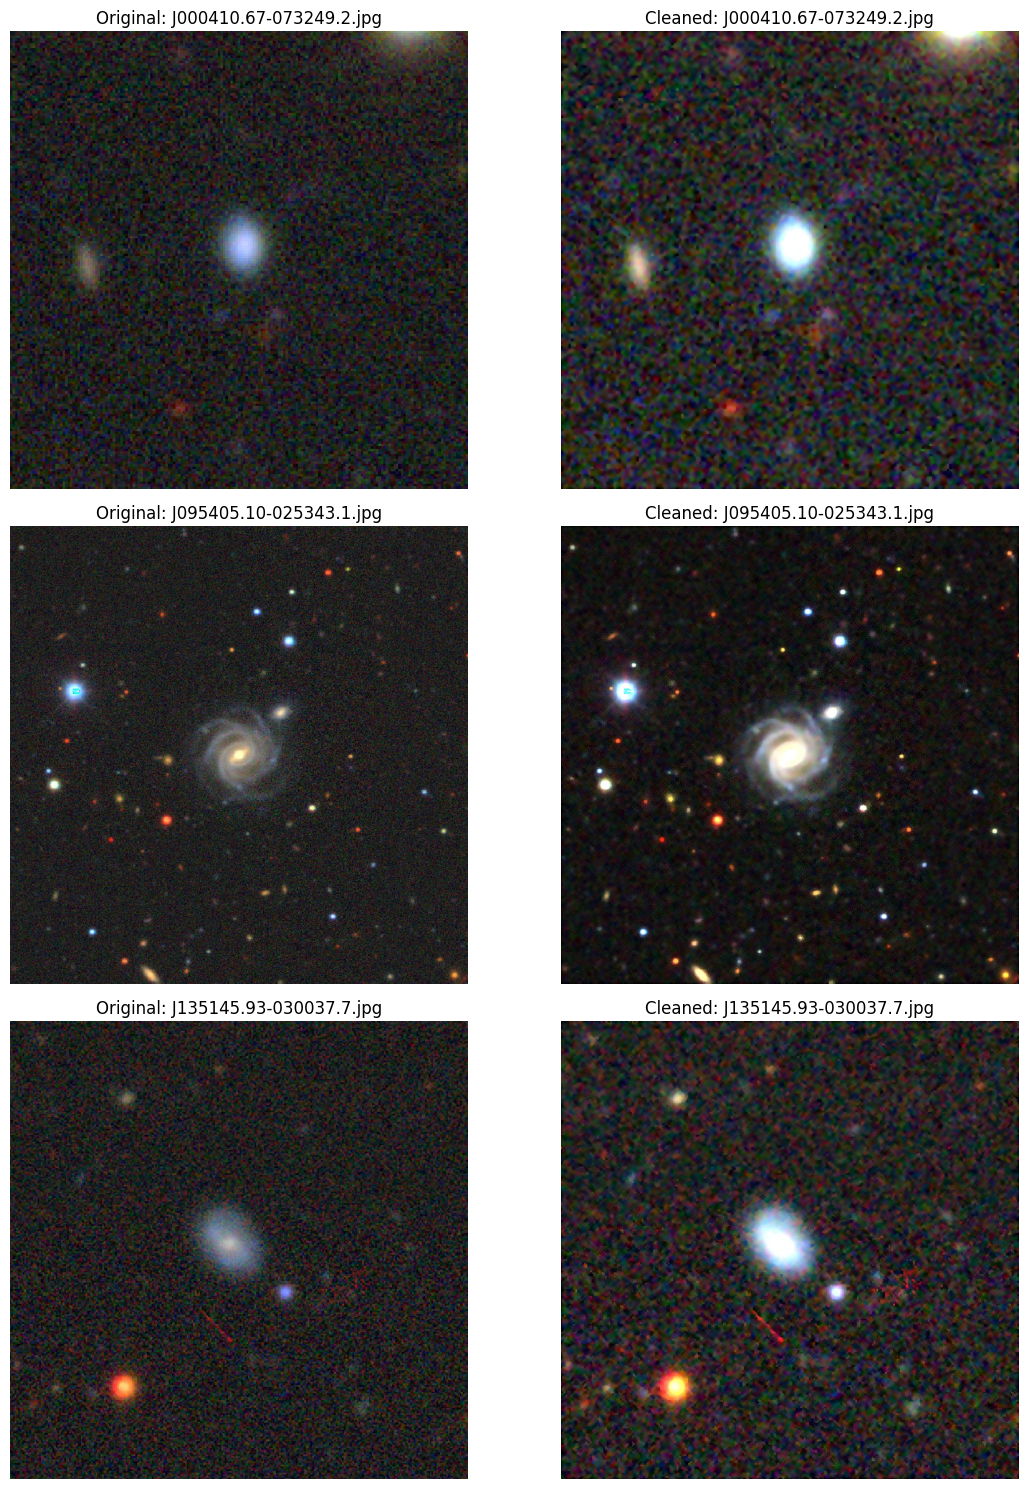

In [19]:
n_to_show = min(3, len(common_files))
print(f"Found {len(common_files)} common images. Selecting {n_to_show} for visualization.")
sample = random.sample(common_files, n_to_show)

fig, axes = plt.subplots(n_to_show, 2, figsize=(12, 5 * n_to_show))

for i, filename in enumerate(sample):
    img_orig = Image.open(SOURCE_PATH / filename)
    axes[i][0].imshow(img_orig)
    axes[i][0].set_title(f"Original: {filename}")
    axes[i][0].axis('off')
    
    img_clean = Image.open(TARGET_PATH / filename)
    axes[i][1].imshow(img_clean)
    axes[i][1].set_title(f"Cleaned: {filename}")
    axes[i][1].axis('off')

plt.tight_layout()
plt.show()